# Stream-CQSA — the paper's figures, from the measurements up

This notebook rebuilds every figure in the paper and in `README.md`:

| figure | what it answers |
|---|---|
| `fig_mem_time_fp16` | how peak memory and wall-clock scale with $N$, and where each method stops |
| `fig_accuracy` | whether decomposing changes the answer |
| `fig_stages_fp16_fwd` / `_bwd` | where the time inside a decomposed run actually goes |

It is written to be read as much as run. Choosing *what to plot* from a
benchmark sweep turned out to be where the mistakes lived — not in the drawing
code — so each selection rule below is stated with the failure it prevents.
Four defects of exactly that kind reached committed figures before being
caught, and each produced a plausible-looking chart rather than an error:

1. a hardcoded method-name prefix that stopped matching after a sweep was
   renamed, so a figure silently drew nothing and last month's copy stayed;
2. out-of-memory rows filtered out before plotting, so every baseline curve
   ended in mid-air with nothing to say why it ended;
3. rows at one $N$ averaged across *decomposition depths*, putting a point on
   the chart that no run produced;
4. memory plotted in MiB, which put the axis top at $10^5$ and made runs look
   as though they had exceeded a card they never exceeded.

The last cell re-derives the published tables from whatever this notebook just
plotted and fails loudly if the two disagree.

## 1. The data

One JSON object per line, one line per measurement. The fields that matter:

| field | meaning |
|---|---|
| `method` | `sdpa`, `sdpa_mem`, `flash`, `cqsa_acccpu`, `cqsa_accgpu_itr1`, … |
| `direction` | `fwd` or `bwd` — measured separately, and they fail at different $N$ |
| `N` | sequence length, 8K … 16M |
| `status` | `ok` or `oom`. **Both are data.** |
| `ms` | wall-clock, milliseconds |
| `mem_alloc_peak` | peak allocated device memory, **MiB** |
| `acc_rel` | relative error against a float64 reference |
| `out_norm` | norm of the output — used to detect incomparable inputs |
| `info.itr` | decomposition depth actually used |
| `stage_ms` | per-stage CUDA-event totals |

Two of these are quiet traps. `mem_alloc_peak` is in MiB while every number in
the paper is quoted in GiB, and the depth is nested inside `info` rather than
sitting at the top level — so code that groups by `(method, N)` alone will
silently merge runs at different depths.

In [1]:
import collections
import json
import os

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator

# Locate the results whether this runs from the development tree or from the
# released package, which put them under a different root.
def find_root():
    here = os.path.abspath("")
    for _ in range(5):
        for rel in ("outputs/paper/results_final",          # dev tree
                    "results/paper/results_final"):         # released package
            if os.path.isdir(os.path.join(here, rel)):
                return here, os.path.join(here, rel)
        here = os.path.dirname(here)
    raise SystemExit("could not locate results_final")

ROOT, FINAL = find_root()
print("results:", os.path.relpath(FINAL, ROOT))

def load(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

# Two sources, deliberately kept apart.
#
# `merged` holds the timing/memory sweep: fp16 only, one row per configuration,
# already deduplicated so that the newest measurement of any cell wins.
#
# The accuracy run is separate because it is a different experiment -- both
# dtypes, ten seeds, a float64 reference, one sequence length. Drawing the
# accuracy figure from `merged` is one of the four mistakes listed above: it
# produces a chart with fp16 only and no reference, and nothing about it looks
# wrong.
TIMING = load(os.path.join(FINAL, "merged", "results.jsonl"))
ACC    = load(os.path.join(FINAL, "sources", "accuracy_20260813.jsonl"))
META   = json.load(open(os.path.join(FINAL, "merged", "meta.json")))

print(f"timing  : {len(TIMING):4d} rows   "
      f"{dict(collections.Counter(r['status'] for r in TIMING))}")
print(f"accuracy: {len(ACC):4d} rows   dtypes="
      f"{sorted({r['dtype'] for r in ACC})}")
print(f"device  : {META['gpu']}  ({META['gpu_gib']} GiB usable)")

results: results/paper/results_final
timing  :  142 rows   {'ok': 133, 'oom': 9}
accuracy:  640 rows   dtypes=['bfloat16', 'float16']
device  : NVIDIA A100 80GB PCIe  (79.3 GiB usable)


## 2. Shared style

Six colour slots, and every series also carries a distinct marker **and** a
distinct dash pattern. Colour alone fails twice over: in greyscale print, and
for the ~8% of male readers with a red–green deficiency. Marker and dash
survive both, so the encoding is redundant on purpose.

Two rules the panels follow:

- **One quantity per axis.** Memory and time are never overlaid on twin
  $y$-axes. Two scales sharing a frame is the single most misleading thing a
  chart of this kind can do — the crossing point is an artifact of the scale
  choice and readers reliably interpret it as a fact.
- **Log on both axes.** $N$ spans $8\,\mathrm{K}$ to $16\,\mathrm{M}$ ($2048\times$)
  and memory spans $0.02$ to $70$ GiB ($3476\times$). On a linear axis every
  point below $N=1\mathrm{M}$ collapses onto the origin.

In [2]:
SLOT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, INK3, GRID = "#0b0b0b", "#52514e", "#8a8880", "#e3e2dd"

# (colour slot, marker, dash) -- one slot per series, assigned in the palette's
# fixed order and never reused. An earlier version put flash and acc=CPU both on
# slot 2 and the two acc=GPU depths both on slot 5, which the validator scores at
# Delta E 0.0: different series, identical colour. Marker and dash still carry
# identity redundantly for greyscale print and red-green deficiency, but they are
# no longer doing the work alone.
STYLE = {
    "sdpa":             (0, "o", (0, ())),
    "sdpa_mem":         (1, "s", (0, (4, 2))),
    "flash":            (2, "^", (0, (6, 2, 1, 2))),
    "cqsa_accgpu_itr1": (3, "D", (0, (3, 1, 1, 1))),
    "cqsa_accgpu_itr2": (4, "v", (0, (1, 1, 3, 1))),
    "cqsa_acccpu":      (5, "*", (0, (5, 1, 1, 1))),
    "cqsa_host_itr1":   (3, "D", (0, (3, 1, 1, 1))),
    "cqsa_host_itr2":   (4, "v", (0, (1, 1, 3, 1))),
}
# The star on "auto" records that the depth was forced to at least 1: the planner
# would have declined to decompose at these lengths, and a column reporting what
# decomposition costs has to actually decompose.
LABEL = {
    "sdpa": "SDPA", "sdpa_mem": "SDPA (mem-eff.)", "flash": "FlashAttention-2",
    "cqsa_accgpu_itr1": "Stream-CQSA  itr=1, acc=GPU",
    "cqsa_accgpu_itr2": "Stream-CQSA  itr=2, acc=GPU",
    "cqsa_acccpu": "Stream-CQSA  itr=auto*, acc=CPU",
    "cqsa_host_itr1": "Stream-CQSA itr=1",
    "cqsa_host_itr2": "Stream-CQSA itr=2",
}
SERIES = ["sdpa", "sdpa_mem", "flash",
          "cqsa_accgpu_itr1", "cqsa_accgpu_itr2", "cqsa_acccpu"]

def nfmt(v, _p=None):
    # 8192 -> 8K, 16777216 -> 16M. Used on both x-scales.
    return (f"{v/1048576:g}M" if v >= 1048576 else
            f"{v/1024:g}K" if v >= 1024 else f"{v:g}")

def style_axes(ax, xlabel, ylabel, title=None, xscale="log"):
    ax.set_xscale("log", base=2) if xscale == "log" else ax.set_xscale("linear")
    ax.set_yscale("log")
    ax.grid(True, which="major", color=GRID, lw=0.7, zorder=0)
    ax.grid(True, which="minor", color=GRID, lw=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(INK3); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors=INK2, labelsize=8, length=3, width=0.8)
    ax.set_xlabel(xlabel, color=INK2, fontsize=9)
    ax.set_ylabel(ylabel, color=INK2, fontsize=9)
    if title:
        ax.set_title(title, color=INK, fontsize=10, pad=6, loc="left")
    ax.xaxis.set_major_formatter(FuncFormatter(nfmt))
    if xscale == "log":
        ax.xaxis.set_major_locator(LogLocator(base=2, numticks=20))
    else:
        ax.set_xlim(0, 16 * 1048576)
        ax.set_xticks([i * 4 * 1048576 for i in range(5)])

print("style defined")

style defined


## 3. Selecting a series — the part that goes wrong

`series_for` turns rows into $(x, y)$ for one method. Three decisions, each of
which was wrong at some point:

**Repeated rows at one $N$ are not all the same kind of repeat.** Several
*seeds* at one $N$ should be averaged. Several *depths* at one $N$ must not be:
$N=16\mathrm{M}$ was measured at `itr=1`, `2` and `3`, and averaging them
plotted the forward at 4467 s / 35.2 GiB — the mean of three depths, a point no
run produced — where the table reports `itr=1` at 3277 s / 41.5 GiB. So depth is
resolved *first*, keeping the smallest that ran, which is the rule the tables
report under; only then are the survivors averaged over seeds.

**An OOM is a measurement.** Keeping only `status == "ok"` makes each curve stop
at the last length that fitted, which reads as *"we didn't measure further"*
when it means *"it cannot run here."* That distinction is the paper's entire
claim. So the first failing $N$ is returned alongside the points and marked with
a ✕ on the chart.

**Which depth is "auto".** The tables report Stream-CQSA under `itr = auto,
acc = CPU`, meaning the smallest depth that fits the memory budget. `itr=1`
satisfies that everywhere except the 16M backward, where three fp32 gradient
buffers do not fit and `itr=2` is the smallest that does. Taking the minimum
present depth reproduces that rule without a special case.

In [3]:
def series_for(rows, method, direction, field, dtype="float16"):
    # Returns (xs, ys, first_oom_N) for one method in one direction.
    # `field` is a row key: "ms" or "mem_alloc_peak".
    pts, depth, oom_n = {}, {}, None

    for r in rows:
        if r["method"] != method or r["dtype"] != dtype:
            continue
        if r["direction"] != direction:
            continue

        if r["status"] == "oom":
            # Remember the shallowest length that failed; a method can have
            # several OOM rows and only the first one is meaningful.
            oom_n = r["N"] if oom_n is None else min(oom_n, r["N"])
            continue
        if r["status"] != "ok":
            continue

        v = r.get(field)
        if v is None or v != v:            # None, or NaN (v != v catches NaN)
            continue

        itr = (r.get("info") or {}).get("itr")
        if itr is not None:
            best = depth.get(r["N"])
            if best is not None and itr > best:
                continue                   # a shallower depth already won here
            if best is None or itr < best:
                depth[r["N"]] = itr
                pts[r["N"]] = []           # deeper samples collected so far go
        pts.setdefault(r["N"], []).append(v)

    xs = sorted(pts)
    ys = [sum(pts[x]) / len(pts[x]) for x in xs]     # now a mean over seeds only
    # The resolved depth per N comes back too, so a panel can label the point
    # where it changes.
    return xs, ys, oom_n, {x: depth[x] for x in xs if x in depth}


# Check it against the case that motivated the rule.
xs, ys, _, _ = series_for(TIMING, "cqsa_acccpu", "fwd", "ms")
raw = [r["ms"] / 1000 for r in TIMING
       if r["method"] == "cqsa_acccpu" and r["direction"] == "fwd"
       and r["N"] == 16_777_216 and r["status"] == "ok"]
print(f"16M forward, acc=CPU")
print(f"  rows present : {[round(t) for t in sorted(raw)]} s   (itr=1,2,3)")
print(f"  naive mean   : {sum(raw)/len(raw):8.1f} s   <- no run produced this")
print(f"  depth-resolved: {ys[xs.index(16_777_216)]/1000:7.1f} s   <- itr=1, what the table reports")

16M forward, acc=CPU
  rows present : [3277, 3896, 6228] s   (itr=1,2,3)
  naive mean   :   4467.1 s   <- no run produced this
  depth-resolved:  3277.4 s   <- itr=1, what the table reports


## 4. Figure 1 — memory and wall-clock

Three decisions here, each of which was wrong in an earlier version.

**Scales: each panel uses the one on which its own growth is a straight line.**
This is the decision that took the longest to get right, and two versions of the
figure were actively misleading before it.

Measured across a doubling of $N$, peak memory grows by $2.00\times$ and time by
$4.0\times$ — memory is linear, time is quadratic. Both were drawn against a
$\log_2$ $x$-axis, which is fine for time (a quadratic on log–log is a straight
line of slope 2) and wrong for memory: a linear function against $\log N$ with a
linear $y$ **must** render as an exploding curve. The memory panel therefore
looked quadratic, arguing against the exact property the method is claimed to
have, and the distortion was entirely in the frame.

So memory is now linear on both axes, zero to the device limit — straight lines
whose slopes differ, which is the finding, and a visible ceiling each one
crosses. Time stays log–log; putting it on a linear $x$ would introduce the
mirror-image error, bending a quadratic over so it appeared to saturate. The
cost of a linear $x$ is that everything below $N=1\mathrm{M}$ collapses toward
the origin, which is honest here: at $8\mathrm{K}$ the peak really is $0.02$ GiB
of an $79.3$ GiB card.

`mem_alloc_peak` is also stored in MiB, and plotting it raw put the axis at
$10^5$ — reading as *100,000-something* against a card holding 80 GiB, so the
runs looked impossible. It is converted to GiB here.

**Out-of-memory is shown as a consequence of the trend, not as a label.** Each
memory curve is continued to the device limit at its own measured slope, and the
✕ marks where the two meet. Because peak memory is linear in $N$, that
continuation is the line the data is already on — and in every case the crossing
lands *below* the next length tested:

| | last measured | trend meets 79.3 GiB | next tested | |
|---|---|---|---|---|
| SDPA fwd | 8M / 40.3 GiB | **15.8M** | 16M | fails |
| FA-2 fwd | 8M / 40.3 GiB | **15.8M** | 16M | fails |
| acc=GPU itr=1 fwd | 8M / 51.8 GiB | **12.2M** | 16M | fails |
| FA-2 bwd | 4M / 40.3 GiB | **7.9M** | 8M | fails |
| acc=GPU itr=1 bwd | 4M / 54.5 GiB | **5.8M** | 8M | fails |

So the reader can see the failure coming instead of taking an annotation's word
for it, and the marks separate themselves — each method meets the ceiling at its
own slope, so the fanning hack an earlier version needed is gone. It survives
only on the time panels, which have no ceiling to cross.

An earlier version placed the ✕ at the last length that *worked*, which put it
one rung to the left of the fact it existed to state: it read as *"SDPA fails at
8M"* when SDPA fails at 16M.

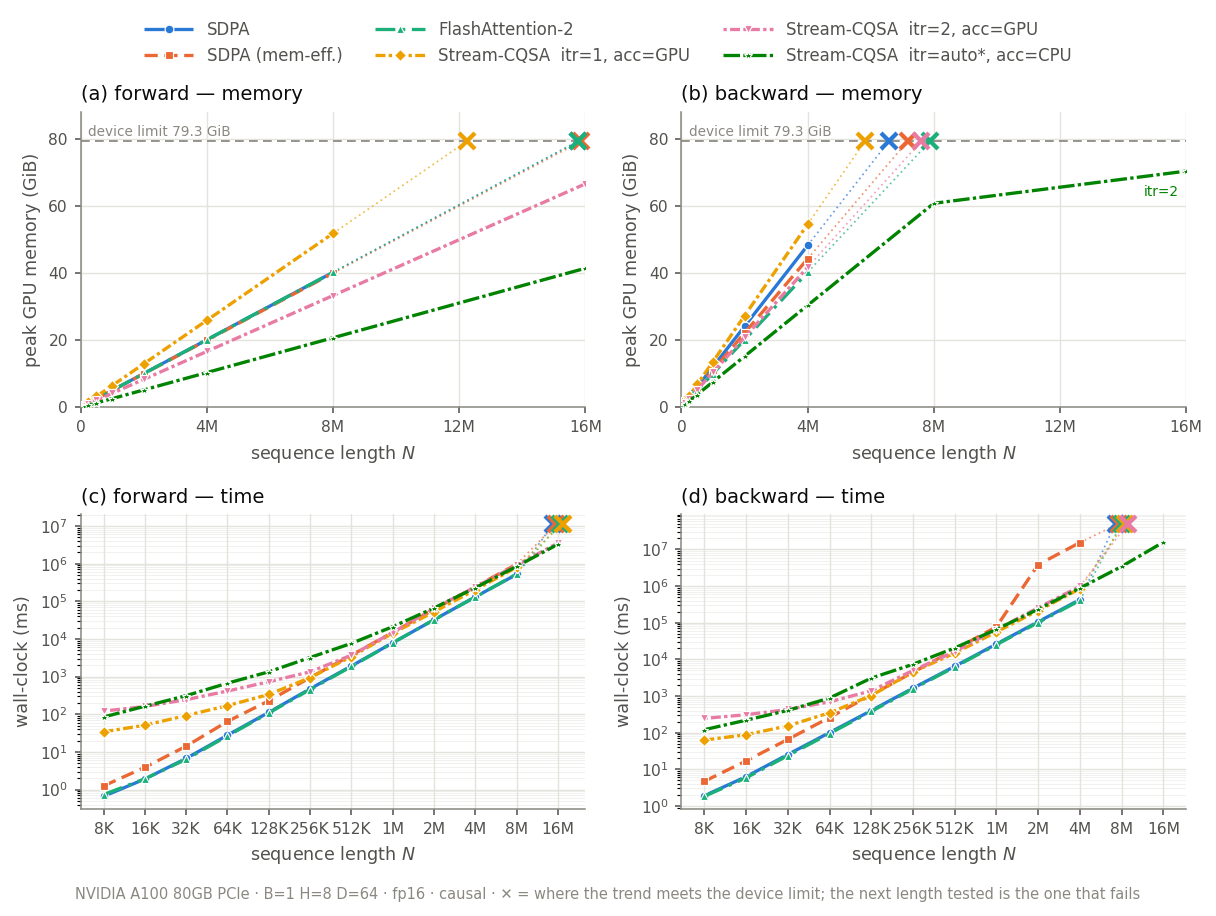

In [4]:
def plot_panel(ax, rows, direction, field, ylabel, title,
               scale=1.0, capacity=None):
    # One panel. `scale` converts the stored unit into the plotted one;
    # `capacity` switches the panel to the memory presentation.
    drew, hi = False, 0.0
    marks = []

    for m in SERIES:
        xs, ys, oom_n, depths = series_for(rows, m, direction, field)
        if not xs:
            continue
        drew = True
        ys = [y * scale for y in ys]
        hi = max(hi, max(ys))
        ci, mk, dash = STYLE[m]
        ax.plot(xs, ys, color=SLOT[ci], marker=mk, ms=4.5, lw=1.7,
                linestyle=dash, label=LABEL[m], zorder=3,
                markeredgecolor="white", markeredgewidth=0.6)
        if oom_n is not None:
            # On the memory panel, continue the measured trend to the device
            # limit and mark where it meets it. Peak memory is linear in N, so
            # that continuation is the line the data is already on -- and in
            # every case here the crossing lands below the next length tested,
            # which is the one that died. The failure becomes something the
            # reader can see coming rather than a label asserting it.
            cross = None
            if capacity and len(xs) >= 2 and xs[-1] != xs[-2]:
                slope = (ys[-1] - ys[-2]) / (xs[-1] - xs[-2])
                if slope > 0:
                    xc = xs[-1] + (capacity - ys[-1]) / slope
                    if xs[-1] < xc <= oom_n:      # only if it explains THIS failure
                        cross = xc
            marks.append((oom_n, xs[-1], ys[-1], SLOT[ci], cross))

        # "auto" is the smallest depth that fits, so it steps up when the
        # previous one stops fitting -- at N=16M in the backward. On a linear
        # axis that step puts a visible bend in an otherwise straight line, and
        # unlabelled it reads as memory growing sub-linearly rather than as a
        # deeper decomposition being bought at that length.
        if capacity and depths:
            for xi, x in enumerate(xs):
                if xi and depths.get(x) is not None and \
                        depths.get(x) != depths.get(xs[xi - 1]):
                    ax.annotate(f"itr={depths[x]}", (x, ys[xi]),
                                textcoords="offset points", xytext=(-4, -13),
                                ha="right", fontsize=7, color=SLOT[ci], zorder=6)

    style_axes(ax, "sequence length $N$", ylabel, title,
               xscale="linear" if capacity else "log")

    if capacity and drew:
        # Linear, zero to the card: the question is what fraction of a fixed
        # ceiling each method reached.
        ax.set_yscale("linear")
        ax.set_ylim(0, capacity * 1.11)
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.axhline(capacity, color=INK3, lw=0.9, ls=(0, (5, 3)), zorder=1)
        ax.text(0.015, capacity * 1.01, f"device limit {capacity:g} GiB",
                transform=ax.get_yaxis_transform(), va="bottom", ha="left",
                color=INK3, fontsize=7)
        y_fail = capacity
    else:
        ax.set_ylim(top=hi * 6 if hi else None)
        y_fail = hi * 3.2 if hi else None

    # Where a projection exists each curve meets the limit at its own slope, so
    # the marks separate themselves. Where there is none -- the time panel has
    # no ceiling to cross -- methods failing at the same length would land on
    # one point and hide each other, so those are fanned around the tick.
    groups = collections.defaultdict(list)
    for mk_ in marks:
        groups[mk_[0] if mk_[4] is None else None].append(mk_)
    for _, group in groups.items():
        k = len(group)
        for i, (n_fail, x_last, y_last, colour, cross) in enumerate(group):
            if y_fail is None:
                continue
            if cross is not None:
                x_mark = cross
            elif k == 1:
                x_mark = n_fail
            elif capacity:
                x_mark = n_fail + (i - (k - 1) / 2) * 0.23e6
            else:
                x_mark = n_fail * (1.052 ** (i - (k - 1) / 2))
            ax.plot([x_last, x_mark], [y_last, y_fail], color=colour, lw=0.9,
                    ls=(0, (1, 2)), zorder=2, alpha=0.7)
            ax.plot([x_mark], [y_fail], marker="x", ms=8, mew=2.2, color=colour,
                    zorder=5, linestyle="none", clip_on=False)
    return drew


fig, axes = plt.subplots(2, 2, figsize=(8.8, 6.4), squeeze=False)
for j, d in enumerate(("fwd", "bwd")):
    name = "forward" if d == "fwd" else "backward"
    plot_panel(axes[0][j], TIMING, d, "mem_alloc_peak",
               "peak GPU memory (GiB)", f"({chr(97+j)}) {name} — memory",
               scale=1/1024, capacity=META["gpu_gib"])
    plot_panel(axes[1][j], TIMING, d, "ms",
               "wall-clock (ms)", f"({chr(99+j)}) {name} — time")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
           fontsize=8.5, labelcolor=INK2, bbox_to_anchor=(0.5, 1.005),
           handlelength=3.0)
fig.text(0.5, 0.008, f"{META['gpu']} · B=1 H=8 D=64 · fp16 · causal · "
         "✕ = where the trend meets the device limit; "
         "the next length tested is the one that fails",
         ha="center", color=INK3, fontsize=7.5)
fig.tight_layout(rect=(0, 0.02, 1, 0.94))
plt.show()

**Reading it.** In the backward every baseline and both device-accumulating
depths stop at $4\mathrm{M}$ — the ✕ marks a failure at $8\mathrm{M}$ — while
`acc=CPU` continues to $16\mathrm{M}$. That gap is the result: the backward
holds three fp32 $[B,N,H,D]$ gradient buffers, 12 bytes per element, and no
depth of decomposition reduces a term that is $O(N)$ by construction. Moving
them off the device does.

The forward tells the milder version of the same story: baselines reach
$8\mathrm{M}$ and fail at $16\mathrm{M}$, where `acc=CPU` fits in 41.5 GiB.

## 5. Figure 2 — accuracy, and one load-bearing filter

A relative error is meaningless except against another error measured on the
same inputs. This run recorded each baseline under **two input regimes** — for
the fp16 forward the output norm is $104.85$ in one group and $3.56$ in the
other — and averaging across them silently rewrites the result: read naively
the baselines come out ~15× worse than Stream-CQSA, which is backwards for a
method whose whole claim is that it *reproduces* them, not that it beats them.

The Stream-CQSA rows form a single regime, so they are the anchor: keep the
rows whose output norm is within 5% of that, drop the rest. It removes 240 of
640 rows. This filter is why the figure and the table agree; without it they
would agree with each other and both be wrong.

The marker is the **median** over ten seeds, matching the table. A mean differs
in the second digit here, which is enough for figure and table to print
different numbers for the same quantity.

In [5]:
OUT_NORM_TOL = 0.05

def median(xs):
    xs = sorted(xs); n = len(xs)
    return xs[n // 2] if n % 2 else 0.5 * (xs[n // 2 - 1] + xs[n // 2])

def same_regime(rows):
    # Keep only rows computed on inputs comparable to the Stream-CQSA runs.
    ok, kept = [r for r in rows if r.get("status") == "ok"], []
    for dt in {r["dtype"] for r in ok}:
        for d in {r["direction"] for r in ok}:
            grp = [r for r in ok if r["dtype"] == dt and r["direction"] == d]
            anchor = [r["out_norm"] for r in grp
                      if r["method"].startswith("cqsa") and r.get("out_norm")]
            if not anchor:
                kept += grp
                continue
            ref = median(anchor)
            kept += [r for r in grp if r.get("out_norm") is not None
                     and abs(r["out_norm"] - ref) <= OUT_NORM_TOL * abs(ref)]
    return kept

kept = same_regime(ACC)
print(f"kept {len(kept)} of {len(ACC)} rows; dropped {len(ACC)-len(kept)} "
      f"from a non-comparable input regime")

# What the filter is protecting against, shown rather than asserted:
for dt, d in (("float16", "fwd"),):
    norms = collections.defaultdict(list)
    for r in ACC:
        if r["dtype"] == dt and r["direction"] == d and r.get("out_norm"):
            norms[round(r["out_norm"], 2)].append(r["method"])
    print(f"\n  {dt} {d}: output norms present -> {sorted(norms)}")
    print( "  a relative error against one is not comparable to one against the other")

kept 400 of 640 rows; dropped 240 from a non-comparable input regime

  float16 fwd: output norms present -> [3.45, 3.47, 3.48, 3.52, 3.53, 3.54, 3.56, 3.6, 103.11, 103.44, 103.55, 104.05, 104.24, 104.76, 104.85, 105.57, 105.9]
  a relative error against one is not comparable to one against the other


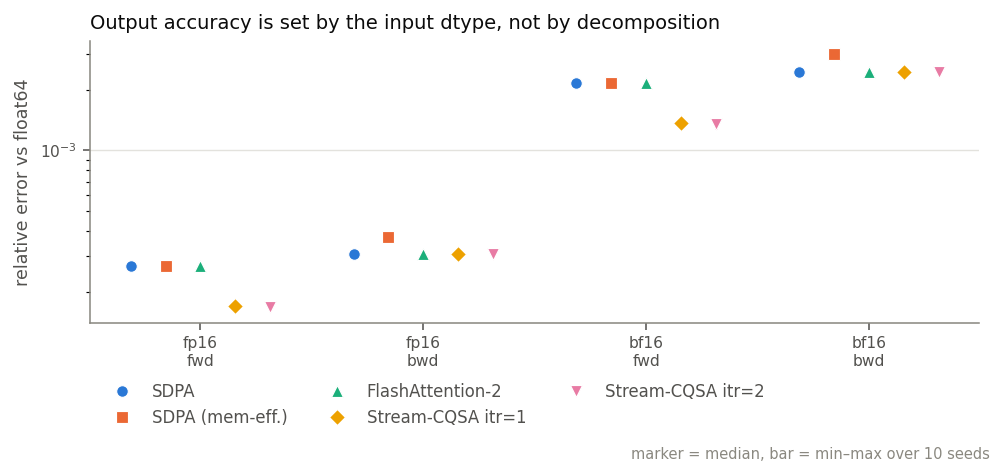

In [6]:
ACC_SERIES = ["sdpa", "sdpa_mem", "flash", "cqsa_host_itr1", "cqsa_host_itr2"]

agg = collections.defaultdict(list)
for r in kept:
    v = r.get("acc_rel")
    if isinstance(v, float) and v == v:
        agg[(r["dtype"], r["direction"], r["method"])].append(v)

cfgs = [(dt, d) for dt in ("float16", "bfloat16") for d in ("fwd", "bwd")]

fig, ax = plt.subplots(figsize=(7.2, 3.4))
xpos, xlab = [], []
for i, (dt, d) in enumerate(cfgs):
    base = i * (len(ACC_SERIES) + 1.4)
    for j, m in enumerate(ACC_SERIES):
        vals = agg.get((dt, d, m))
        if not vals:
            continue
        ci, mk, _ = STYLE[m]
        x = base + j
        ax.plot([x], [median(vals)], marker=mk, ms=6, color=SLOT[ci], zorder=3,
                markeredgecolor="white", markeredgewidth=0.6, linestyle="none",
                label=LABEL[m] if i == 0 else None)
        # Spread over seeds, so a single median cannot hide a wide spread.
        ax.plot([x, x], [min(vals), max(vals)], color=SLOT[ci], lw=1.4,
                alpha=0.55, zorder=2)
    xpos.append(base + (len(ACC_SERIES) - 1) / 2)
    xlab.append(f"{'fp16' if dt=='float16' else 'bf16'}\n{d}")

ax.set_yscale("log")
ax.set_xticks(xpos); ax.set_xticklabels(xlab, color=INK2, fontsize=9)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(INK3); ax.spines[s].set_linewidth(0.8)
ax.tick_params(colors=INK2, labelsize=8)
ax.set_ylabel("relative error vs float64", color=INK2, fontsize=9)
ax.set_title("Output accuracy is set by the input dtype, not by decomposition",
             color=INK, fontsize=10, loc="left", pad=6)
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, ncol=3,
          loc="upper left", bbox_to_anchor=(0, -0.16))
fig.text(0.99, 0.02, "marker = median, bar = min–max over 10 seeds",
         ha="right", color=INK3, fontsize=7.5)
fig.tight_layout()
plt.show()

**Reading it.** In the *backward* all four series sit on top of each other:
decomposing changes nothing, which is what an exact decomposition should do.

In the *forward* Stream-CQSA sits visibly **below** the baselines, and that is
not a sharper arithmetic — it is a different return type. The baselines return
the output in the input dtype and so land on the fp16 rounding floor near
$2.7\times10^{-4}$; Stream-CQSA accumulates in fp32 and returns fp32, so the
output is never rounded down at all. Cast it to fp16 and the two agree. The
backward row is the like-for-like comparison, both paths returning fp32.

## 6. Figure 3 — where the time goes

Six panels: three configurations — two decomposition depths with the
accumulators on the device, and the host-resident configuration the tables lead
with — in both directions. The grid is the point. It separates what follows the
*depth* from what follows the *residency choice*, which a single panel cannot.

Two further decisions here, and the first reversed a claim in the paper.

**Shares, not totals; linear, not log.** The original drew stacked
milliseconds on a log axis. That cannot be read: on a log scale a stacked
segment's height is not proportional to its value, so whichever stage is
largest looks dominant whatever the split actually is, and the four shortest
lengths compressed to nothing against a $10^7$ ms top. Drawn as proportions,
the same data shows a crossover the stacked version hid — in the backward the
local kernel is $14\%$ of issued work at $8\mathrm{K}$ and $98\%$ by
$4\mathrm{M}$. The paper had claimed the kernel "dominates at every length
measured", which is false below $64\mathrm{K}$.

**`wait` is excluded.** It measures time an event span spent queued behind
another stream, so it runs *concurrently* with the work it would be stacked on
top of — at $16\mathrm{M}$ it lands within $0.2\%$ of `compute` for exactly
that reason. It is a real cost in wall-clock terms, but it is not a share of
anything, and putting it in a proportion double-counts the concurrency.

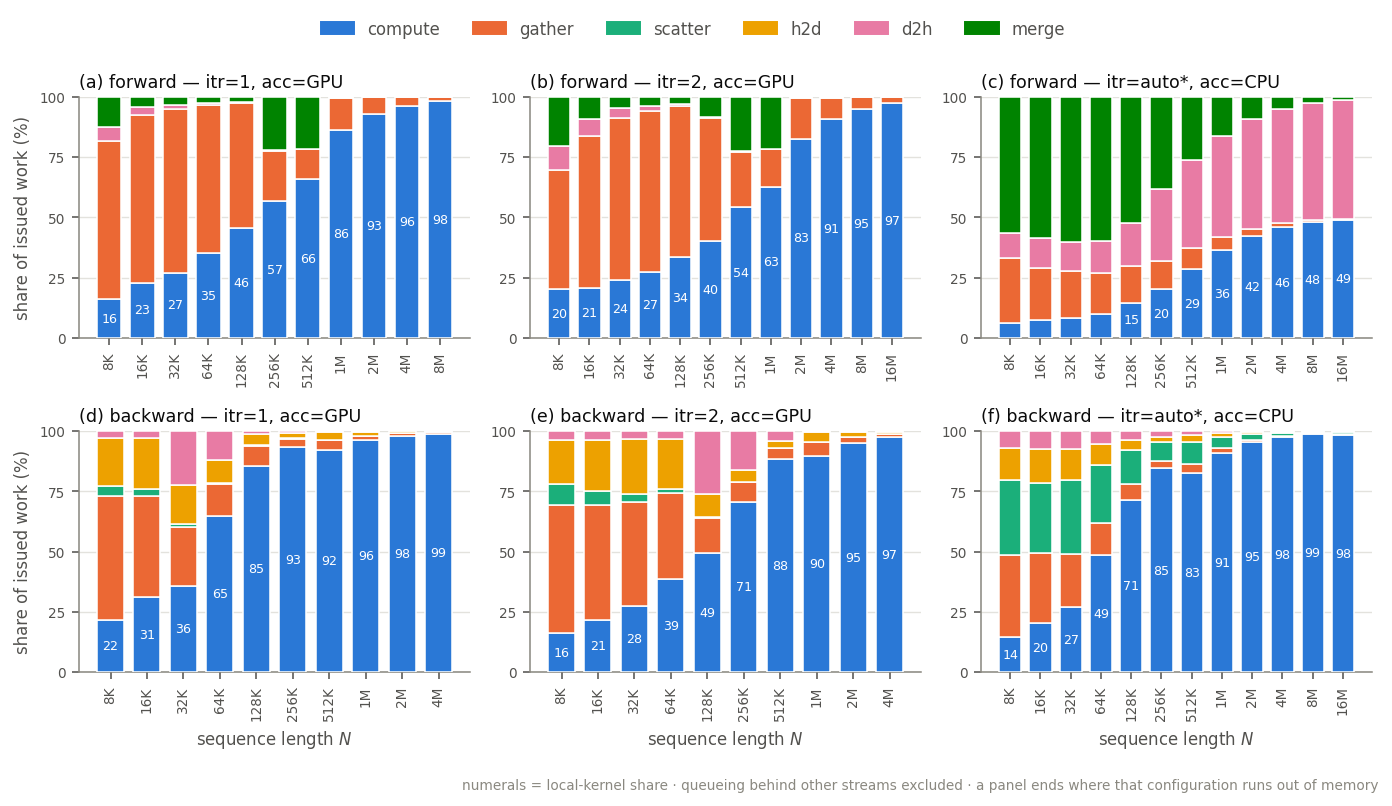

In [7]:
def stage_rows(rows, direction, dtype="float16", method=None):
    # One Stream-CQSA row per N, at the shallowest depth measured.
    cand = [r for r in rows
            if r["dtype"] == dtype and r["direction"] == direction
            and r["status"] == "ok" and r.get("stage_ms")
            # Match the family, never a literal method name: the runner encodes
            # each sweep's configuration into that name, so a hardcoded prefix
            # stops matching the moment a sweep is renamed -- and the figure
            # then draws nothing at all rather than raising.
            and r["method"].startswith("cqsa")]
    if not cand:
        return [], None
    if method is None:
        names = sorted({r["method"] for r in cand})
        method = next((m for m in names if "acccpu" in m), names[0])
    by_n = {}
    for r in (x for x in cand if x["method"] == method):
        itr = (r.get("info") or {}).get("itr")
        prev = by_n.get(r["N"])
        if prev is None or (itr is not None and
                            itr < (prev.get("info") or {}).get("itr", 1 << 30)):
            by_n[r["N"]] = r
    return [by_n[n] for n in sorted(by_n)], method


CONFIGS = [("cqsa_accgpu_itr1", "itr=1, acc=GPU"),
           ("cqsa_accgpu_itr2", "itr=2, acc=GPU"),
           ("cqsa_acccpu",      "itr=auto*, acc=CPU")]

# Stack order, and so the adjacent pairs the palette was validated on.
STAGE_ORDER = ("compute", "gather", "scatter", "h2d", "d2h", "merge")


def stage_panel(ax, rows, direction, method, title):
    keep, _ = stage_rows(rows, direction, method=method)
    if not keep:
        ax.set_axis_off()
        return []

    seen = {k for r in keep for k in r["stage_ms"] if k != "wait"}
    pref = [st for st in STAGE_ORDER if st in seen] + sorted(seen - set(STAGE_ORDER))

    # Normalise each length to 100%.
    shares = []
    for r in keep:
        d = {k: v for k, v in r["stage_ms"].items() if k != "wait"}
        tot = sum(d.values()) or 1.0
        shares.append({k: 100 * d.get(k, 0.0) / tot for k in pref})

    xs = list(range(len(keep)))
    bottom = [0.0] * len(keep)
    for st in pref:
        vals = [sh[st] for sh in shares]
        ax.bar(xs, vals, bottom=bottom, width=0.74,
               color=SLOT[STAGE_ORDER.index(st) % len(SLOT)], label=st,
               zorder=3, edgecolor="white", linewidth=0.8)
        bottom = [b + v for b, v in zip(bottom, vals)]

    # The kernel's share is the number the text argues from, so print it rather
    # than leaving the reader to estimate it off the axis.
    for x, sh in zip(xs, shares):
        c = sh.get("compute", 0.0)
        if c >= 12:                     # below this the numeral will not fit
            ax.text(x, c / 2, f"{c:.0f}", ha="center", va="center",
                    fontsize=6.5, color="white", zorder=4)

    ax.set_xticks(xs)
    ax.set_xticklabels([f"{r['N']//1024}K" if r["N"] < 1048576
                        else f"{r['N']//1048576}M" for r in keep],
                       color=INK2, fontsize=7, rotation=90)
    ax.set_ylim(0, 100); ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(INK3); ax.spines[sp].set_linewidth(0.8)
    ax.tick_params(colors=INK2, labelsize=7)
    ax.set_title(title, color=INK, fontsize=9, loc="left", pad=5)
    return pref


fig, axes = plt.subplots(2, 3, figsize=(10.0, 5.6), squeeze=False)
stages = []
for i, d in enumerate(("fwd", "bwd")):
    for j, (method, name) in enumerate(CONFIGS):
        pref = stage_panel(axes[i][j], TIMING, d, method,
                           f"({chr(97 + i*3 + j)}) "
                           f"{'forward' if d == 'fwd' else 'backward'} — {name}")
        stages += [st for st in pref if st not in stages]
    axes[i][0].set_ylabel("share of issued work (%)", color=INK2, fontsize=8.5)
for j in range(3):
    axes[1][j].set_xlabel("sequence length $N$", color=INK2, fontsize=8.5)

order = [st for st in STAGE_ORDER if st in stages]
fig.legend([plt.Rectangle((0, 0), 1, 1,
                          color=SLOT[STAGE_ORDER.index(st) % len(SLOT)])
            for st in order], order,
           loc="upper center", ncol=len(order), frameon=False, fontsize=8.5,
           labelcolor=INK2, bbox_to_anchor=(0.5, 1.005))
fig.text(0.99, 0.005,
         "numerals = local-kernel share · queueing behind other streams excluded"
         " · a panel ends where that configuration runs out of memory",
         ha="right", color=INK3, fontsize=7)
fig.tight_layout(rect=(0, 0.025, 1, 0.945))
plt.show()

**Reading them.** Depth is the lesser variable; residency is the larger one.

Both device-resident depths converge on the same profile — the local kernel at
$98\%$ by the largest length each completes — and differ mainly in where the
crossover falls. The host-resident forward never converges at all.

The two directions differ, and the difference is structural.

The *backward* crosses over near $64\mathrm{K}$: below it the index
construction that assembles and disperses each subsequence dominates, above it
the local kernel does, reaching $98\%$ by $4\mathrm{M}$. The bookkeeping and
transfers are linear in $N$ while the attention within each subsequence is
quadratic in the subsequence length, so decomposition's fixed costs are
amortized in exactly the regime the method exists for — and paid in full where
decomposition was unnecessary to begin with. That is the case the OOM guardrail
exists to decline.

The *forward* never crosses over. Device-to-host transfer converges on the
kernel instead of falling away — $3.1$ points apart at $2\mathrm{M}$, $0.4$ at
$16\mathrm{M}$, where the two stand at $49\%$ each. Returning an $O(N)$ fp32
accumulator to the host is intrinsically comparable in cost to producing it,
and no scheduling change removes that.

## 7. Does any of this match the published tables?

Every figure above is a claim about numbers that also appear in
`README.md` and in the paper. The two are built by different code from the
same rows, so they can disagree — and they have. This cell re-derives each
plotted point and compares it against the committed CSVs.

It is the check that would have caught three of the four defects at the top of
this notebook.

In [8]:
import csv

table = {}
with open(os.path.join(FINAL, "tables", "exp23_time_memory.csv")) as f:
    for r in csv.DictReader(f):
        table[(int(r["N"]), r["direction"], r["method"])] = (
            float(r["seconds"]), float(r["peak_gib"]))

bad = checked = 0
for m in SERIES:
    for d in ("fwd", "bwd"):
        xs, ys, _, _ = series_for(TIMING, m, d, "ms")
        xm, ym, _, _ = series_for(TIMING, m, d, "mem_alloc_peak")
        for x, y in zip(xs, ys):
            if (x, d, m) not in table:
                continue
            checked += 1
            want_s, want_g = table[(x, d, m)]
            got_s, got_g = y / 1000, ym[xm.index(x)] / 1024
            if (abs(want_s - got_s) > max(0.002, 0.01 * want_s) or
                    abs(want_g - got_g) > max(0.02, 0.01 * want_g)):
                bad += 1
                print(f"  MISMATCH {m} {d} N={x}: "
                      f"plotted {got_s:.3f}s/{got_g:.2f}GiB, "
                      f"table {want_s:.3f}s/{want_g:.2f}GiB")

print(f"timing:   {checked} plotted points vs the table -> {bad} mismatches")

# ... and the accuracy figure against the accuracy table.
md_txt = open(os.path.join(FINAL, "tables", "exp1_accuracy.md")).read()
acc_bad = acc_checked = 0
for dt, head in (("float16", "### fp16"), ("bfloat16", "### bf16")):
    block = md_txt.split(head)[1]
    for d, rowname in (("fwd", "**forward**"), ("bwd", "**backward**")):
        line = next(l for l in block.splitlines() if l.startswith("| " + rowname))
        cells = [c.strip() for c in line.split("|")[2:-1]]
        for i, m in enumerate(ACC_SERIES):
            acc_checked += 1
            if f"{median(agg[(dt, d, m)]):.2e}" != cells[i]:
                acc_bad += 1
                print(f"  MISMATCH acc {dt} {d} {m}")
print(f"accuracy: {acc_checked} cells vs the table -> {acc_bad} mismatches")

assert bad == 0 and acc_bad == 0, "figures disagree with the published tables"
print("\nevery plotted value matches the published tables")

timing:   87 plotted points vs the table -> 0 mismatches
accuracy: 20 cells vs the table -> 0 mismatches

every plotted value matches the published tables


## Regenerating the committed figures

This notebook is the annotated version. The files the paper and README include
are produced by a script, from the same rows and the same rules:

```bash
python experiments/paper/build_final_tables.py    # tables + merged/results.jsonl
python experiments/paper/build_final_figures.py   # the four figures
```

The table builder writes `merged/results.jsonl`, and the figure builder reads
only that — so a figure cannot be drawn from rows the tables excluded. The
figure builder fails the build if any figure draws nothing, which is what makes
defect (1) at the top an error rather than a stale file left quietly in place.